## Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time 
import json

## Reading in Data

In [2]:
data = pd.read_csv('../Data/exon_ranges_summary.csv')

#### Getting only species name from CSV and converting to JSON

In [4]:
print('list length:', len(data['Species']))
print('unique species:', len(data['Species'].unique()))


list length: 318
unique species: 318


In [10]:
all_species_names = data['Species'].unique()
# convert species names only to JSON

def write_to_json(data, filename):
    species_json = []
    for i in data:
        species_json.append({'species': i})

    with open(filename, 'w') as json_file:
        json.dump(species_json, json_file, indent=4)

write_to_json(all_species_names, 'species.json')

In [26]:
display(data)

,Species,Genome_size,Positive Strand Range,Negative Strand Range,Average Range,Exon_to_genome_ratio
0,Accipiter_nisus.Accipiter_nisus_ver1.0.112,1190649881,507389,559342,533365,0.000448
1,Ailuropoda_melanoleuca.ASM200744v2.112,2444060653,21311117,21448659,21379888,0.008748
2,Amazona_collaria.ASM394721v1.112,1258720284,10326052,9915899,10120975,0.008041
3,Amphilophus_citrinellus.Midas_v5.112,844902565,3522304,3498842,3510573,0.004155
4,Amphiprion_ocellaris.ASM2253959v1.112,863484803,23552001,23694595,23623298,0.027358
...,...,...,...,...,...,...
313,Xiphophorus_couchianus.Xiphophorus_couchianus-...,708396389,11227574,11406256,11316915,0.015975
314,Xiphophorus_maculatus.X_maculatus-5.0-male.112,704321165,21510297,21358966,21434631,0.030433
315,Zalophus_californianus.mZalCal1.pri.112,2408641788,23980476,23606709,23793592,0.009878
316,Zonotrichia_albicollis.Zonotrichia_albicollis-...,1052600561,7425546,7244961,7335253,0.006969


## Simulation function

Defaults creating a CSV to False. (so don't get a ton of .csv's)

work in progress! 

In [9]:

def get_results_dictionary(species_data, simulation_rounds, genome_size, num_active_te, range_1_start, range_1_end, range_2_start, range_2_end):
     # Dictionary to store the results
        species_results = {
            'Species': species_data['Species'],
            'Beginning Genome Size': genome_size,
            'Exon Start Range': range_1_start,
            'Exon End Range': range_1_end,
            'Non-Coding Start Range': range_2_start,
            'Non-Coding End Range': range_2_end,
            'Active TEs': num_active_te,
            'TEs mobilized': 0,
            'TEs static': 0,
            'TEs in Exons': 0,
            'TEs in Non-Coding': 0,
            'Exon New Size': range_1_end - range_1_start + 1,
            'Non-Coding New Size': range_2_end - range_2_start + 1,
            'Total Genome Growth': 0,
            'Simulation Rounds': simulation_rounds,
            'Total Time': 0
        }
        return species_results


def get_te_lengths(num_active_te, mean_length=5000, std_dev_length=2000):
    te_lengths = np.random.normal(loc=mean_length, scale=std_dev_length, size=num_active_te)
    te_lengths = np.clip(te_lengths, 100, 10000).astype(int)
    return te_lengths


def simulation(data, simulation_rounds=1000, num_active_te=1000, te_mobilize_threshold=0.5, num_species=1, to_csv=False):
    # get TE lengths
    te_lengths = get_te_lengths(num_active_te)

    results_list = []
    
    for i in range(num_species):
        species_data = data.iloc[i]
    

        genome_size = species_data['Genome_size']
        initial_genome_size = genome_size
        average_range = species_data['Average Range']

        exon_range_start, exon_range_end = 0, average_range
        nc_range_start, nc_range_end = average_range + 1, genome_size

        results = get_results_dictionary(species_data, simulation_rounds, genome_size, num_active_te, exon_range_start, exon_range_end, nc_range_start, nc_range_end)

        start_time = time.time()

        for _ in range(simulation_rounds): 
            for _ in range(num_active_te):
                te_length = random.choice(te_lengths) # randomly select a TE length from normal distribution
                if random.random() < te_mobilize_threshold:
                    # prob_exon = exon_range_end / genome_size # probability of TE landing in exon: use this?
                    te_position = random.randint(0, genome_size)
                    # print(f'TE position: {te_position}')

                    if te_position <= exon_range_end: # lands in exon (range 1) or random.random() < prob_exon:
                        exon_range_end += te_length # expand range 1
                        nc_range_start = exon_range_end + 1
                        nc_range_end += te_length # expand range 2 
                        results['TEs in Exons'] += 1
                        genome_size += te_length # increment genome size
                    else:
                        nc_range_end += te_length # expand range 2
                        results['TEs in Non-Coding'] += 1 # increment count for non-coding TEs
                        genome_size += te_length # increment genome size
        
                    results['TEs mobilized'] += 1
                else:
                    results['TEs static'] += 1

        end_time = time.time()
        results['Exon New Size'] = exon_range_end - exon_range_start + 1
        results['Non-Coding New Size'] = nc_range_end - nc_range_start + 1
        results['Total Genome Growth'] = results['Exon New Size'] + results['Non-Coding New Size'] - initial_genome_size
        results['Total Time'] = end_time - start_time

        results_list.append(results)

    results_df = pd.DataFrame(results_list) # , index=[0])

    # save to DataFrame
    if to_csv:
        results_df.to_csv('CSV/simulation_results.csv', index=False)
    return results_df

## Run simulation 

can do other species or all species, just change what is being passed to function. Change csv to true below if you would like to see the .csv

In [10]:
species_df = simulation(data, num_species=318, to_csv=False)
species_df

,Species,Beginning Genome Size,Exon Start Range,Exon End Range,Non-Coding Start Range,Non-Coding End Range,Active TEs,TEs mobilized,TEs static,TEs in Exons,TEs in Non-Coding,Exon New Size,Non-Coding New Size,Total Genome Growth,Simulation Rounds,Total Time
0,Accipiter_nisus.Accipiter_nisus_ver1.0.112,1190649881,0,533365,533366,1190649881,1000,499411,500589,180,499231,1432757,3706867260,2517650136,1000,0.627838
1,Ailuropoda_melanoleuca.ASM200744v2.112,2444060653,0,21379888,21379889,2444060653,1000,501180,498820,4599,496581,44644961,4927625661,2528209969,1000,0.630918
2,Amazona_collaria.ASM394721v1.112,1258720284,0,10120975,10120976,1258720284,1000,500702,499298,4094,496608,30980742,3754420116,2526680574,1000,0.634659
3,Amphilophus_citrinellus.Midas_v5.112,844902565,0,3510573,3510574,844902565,1000,500321,499679,2062,498259,13872948,3355054159,2524024542,1000,0.601301
4,Amphiprion_ocellaris.ASM2253959v1.112,863484803,0,23623298,23623299,863484803,1000,498931,501069,13890,485041,93608674,3285035535,2515159406,1000,0.609861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313,Xiphophorus_couchianus.Xiphophorus_couchianus-...,708396389,0,11316915,11316916,708396389,1000,499793,500207,8118,491675,52033677,3177095983,2520733271,1000,0.630718
314,Xiphophorus_maculatus.X_maculatus-5.0-male.112,704321165,0,21434631,21434632,704321165,1000,499555,500445,15269,484286,98066781,3123344861,2517090477,1000,0.640816
315,Zalophus_californianus.mZalCal1.pri.112,2408641788,0,23793592,23793593,2408641788,1000,500424,499576,4997,495427,49085783,4880717023,2521161018,1000,0.675857
316,Zonotrichia_albicollis.Zonotrichia_albicollis-...,1052600561,0,7335253,7335254,1052600561,1000,500398,499602,3599,496799,25574932,3549850925,2522825296,1000,0.685028


## Visualize the results

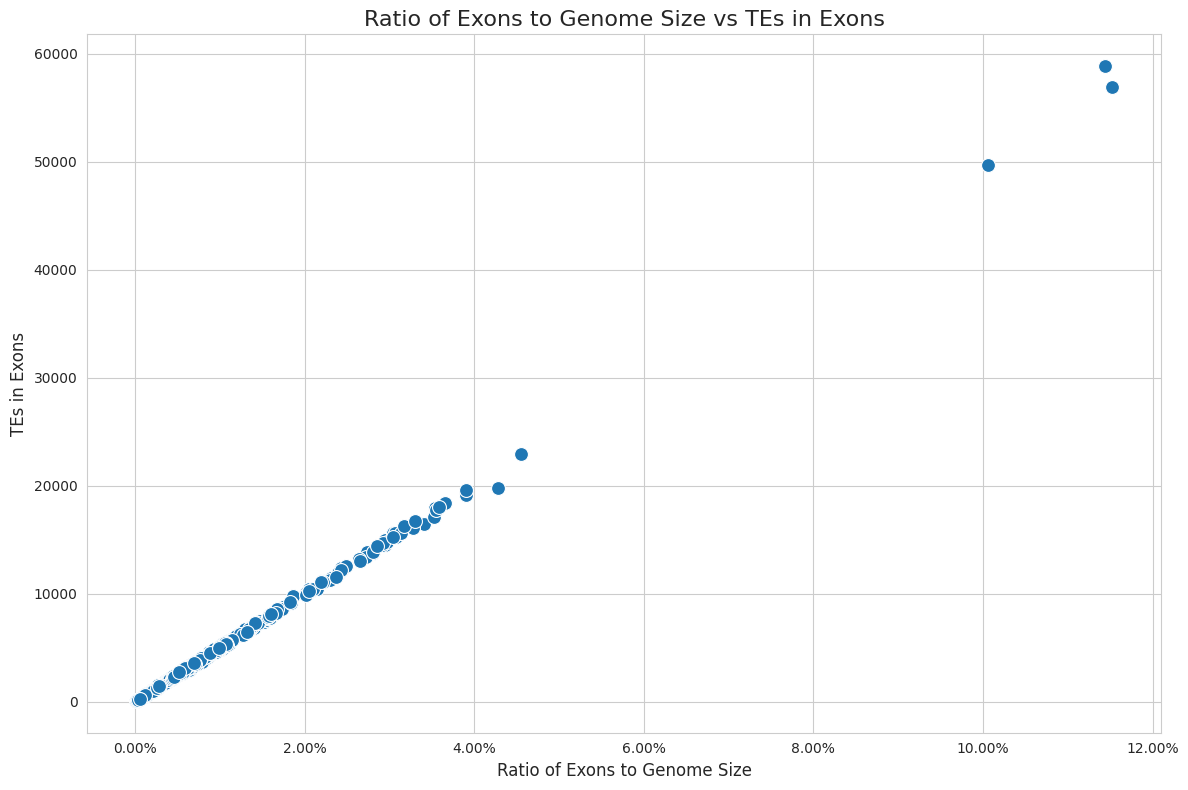

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the exon to genome ratio
species_df["exon_to_genome_ratio"] = species_df["Exon End Range"] / species_df["Beginning Genome Size"]

# Set up the plot style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Create the scatter plot
sns.scatterplot(data=species_df, x='exon_to_genome_ratio', y='TEs in Exons', s=100)

# Customize the plot
plt.title('Ratio of Exons to Genome Size vs TEs in Exons', fontsize=16)
plt.xlabel('Ratio of Exons to Genome Size', fontsize=12)
plt.ylabel('TEs in Exons', fontsize=12)

# Format x-axis to display percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.2%}"))

# Show the plot
plt.tight_layout()
plt.show()